# Manual trading Round 1

Simulate the auction for Mushrooms, assuming our order gets executed after those with higher prices and already in the book (price-time priority)

Optimal Strategy Found:
Price:  19
Volume: 40,999
Profit: 79,948.05


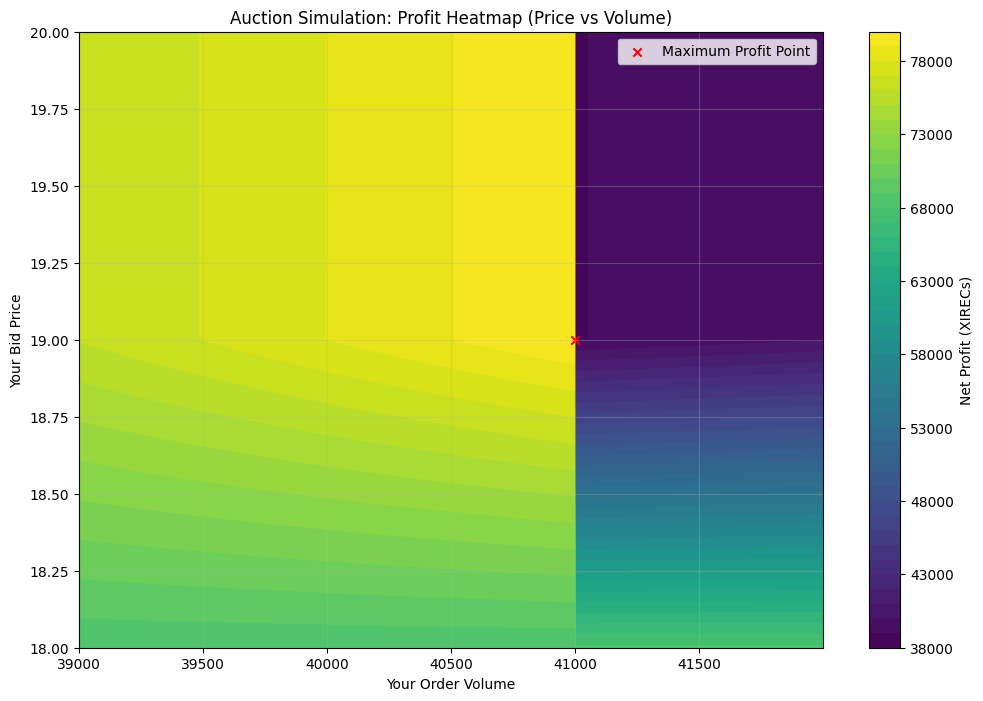

In [9]:
def simulate_auction(my_bid_price, my_bid_volume, terminal_value=20, fee=0.05):
    # Data from the Ember Mushroom stale book
    # Sorted Asks: (Price, Volume) - Ascending
    asks = [[12, 20000], [13, 25000], [14, 35000], [15, 6000], [16, 5000], [18, 10000], [19, 12000]]
    
    # Sorted Bids: (Price, Volume, is_me) - Descending
    # Note: I'm adding 'is_me' to track your specific fill
    bids = [
        [20, 43000, False],
        [19, 17000, False],
        [18, 6000, False],
        [17, 5000, False],
        [16, 10000, False],
        [15, 5000, False],
        [14, 10000, False],
        [13, 7000, False]
    ]
    
    # Add your order to the list
    bids.append([my_bid_price, my_bid_volume, True])
    # Re-sort bids by price (descending). 
    # Python's sort is stable, so you'll be behind existing orders at the same price.
    bids.sort(key=lambda x: x[0], reverse=True)

    total_my_fill = 0
    
    # Single-price auction matching engine
    all_prices = sorted(list(set([a[0] for a in asks] + [b[0] for b in bids])), reverse=True)
    clearing_price = None
    max_volume = 0

    # Find the price that maximizes total traded volume, then breaks ties with the higher price
    for p in all_prices:
        total_bid_vol = sum(b[1] for b in bids if b[0] >= p)
        total_ask_vol = sum(a[1] for a in asks if a[0] <= p)
        volume_at_p = min(total_bid_vol, total_ask_vol)
        
        if volume_at_p > max_volume:
            max_volume = volume_at_p
            clearing_price = p
        elif volume_at_p == max_volume and max_volume > 0:
            # Rule: Choose the higher price in case of a volume tie
            if p > (clearing_price if clearing_price is not None else -float('inf')):
                clearing_price = p # Actually, this never gets run because we sorted it largest-to-smallest earlier. 
                
    # print("Clearing price:", clearing_price)
    # Execute all trades at the single clearing_price
    if clearing_price is not None:
        eligible_asks = sorted([a for a in asks if a[0] <= clearing_price], key=lambda x: x[0])
        eligible_bids = sorted([b for b in bids if b[0] >= clearing_price], key=lambda x: x[0], reverse=True)
        
        remaining_supply = max_volume
        for ask in eligible_asks:
            if remaining_supply <= 0: break
            
            ask_match = min(ask[1], remaining_supply)
            remaining_supply -= ask_match
            ask[1] -= ask_match
            
            # Match against bids in priority order
            demand_to_fill = ask_match
            for bid in eligible_bids:
                if demand_to_fill <= 0: break
                
                match_vol = min(bid[1], demand_to_fill)
                if bid[2]: # is_me
                    total_my_fill += match_vol
                
                bid[1] -= match_vol
                demand_to_fill -= match_vol

    profit = total_my_fill * (terminal_value - clearing_price - fee)
    return total_my_fill, profit

import matplotlib.pyplot as plt
import numpy as np

# Testing different scenarios for price and volume
prices_to_test = np.arange(18, 21, 1)  # Test range around the fair value - we know the ideal is 19
volumes_to_test = np.arange(39000, 42000, 1)  # Test a narrow range - we know the ideal is near 19, 40,000

results_profit = np.zeros((len(prices_to_test), len(volumes_to_test)))
results_fill = np.zeros((len(prices_to_test), len(volumes_to_test)))

best_profit = -float('inf')
best_config = (0, 0)

# Simulate the grid
for i, p in enumerate(prices_to_test):
    for j, v in enumerate(volumes_to_test):
        fill, profit = simulate_auction(p, v)
        results_profit[i, j] = profit
        results_fill[i, j] = fill
        
        if profit > best_profit:
            best_profit = profit
            best_config = (p, v)

# Output the result of the "Main Character" nudge
print(f"Optimal Strategy Found:")
print(f"Price:  {best_config[0]}")
print(f"Volume: {best_config[1]:,.0f}")
print(f"Profit: {best_profit:,.2f}")

# Visualization
plt.figure(figsize=(12, 8))
plt.contourf(volumes_to_test, prices_to_test, results_profit, levels=50, cmap='viridis')
plt.colorbar(label='Net Profit (XIRECs)')
plt.scatter(best_config[1], best_config[0], color='red', marker='x', label='Maximum Profit Point')

plt.title('Auction Simulation: Profit Heatmap (Price vs Volume)')
plt.xlabel('Your Order Volume')
plt.ylabel('Your Bid Price')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Below is the same simulation for FLAX

Optimal Strategy Found:
Price:  29
Volume: 4,999
Profit: 9,998.00


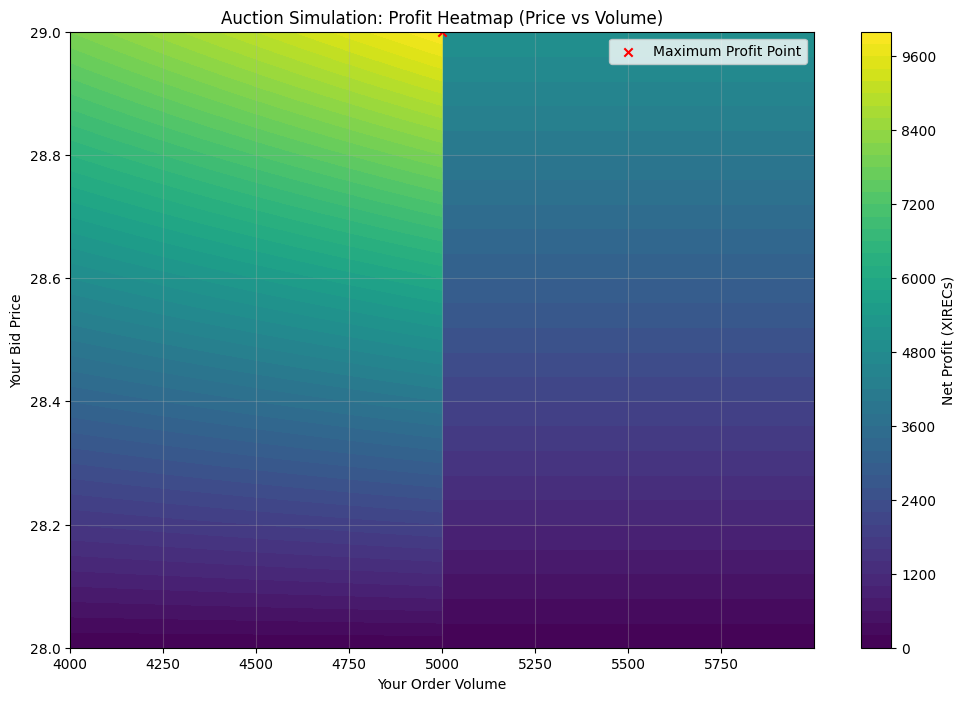

In [10]:
def simulate_auction(my_bid_price, my_bid_volume, terminal_value=30, fee=0):
    # Data from the Flax stale book
    # Sorted Asks: (Price, Volume) - Ascending
    asks = [[28, 40000], [31, 20000], [32, 20000], [33, 30000]]
    
    # Sorted Bids: (Price, Volume, is_me) - Descending
    # Note: I'm adding 'is_me' to track your specific fill
    bids = [
        [30, 30000, False],
        [29, 5000, False],
        [28, 12000, False],
        [27, 28000, False],
    ]
    
    # Add your order to the list
    bids.append([my_bid_price, my_bid_volume, True])
    # Re-sort bids by price (descending). 
    # Python's sort is stable, so you'll be behind existing orders at the same price.
    bids.sort(key=lambda x: x[0], reverse=True)

    total_my_fill = 0
    
    
    # Single-price auction matching engine
    all_prices = sorted(list(set([a[0] for a in asks] + [b[0] for b in bids])), reverse=True)
    clearing_price = None
    max_volume = 0

    # Find the price that maximizes total traded volume, then breaks ties with the higher price
    for p in all_prices:
        total_bid_vol = sum(b[1] for b in bids if b[0] >= p)
        total_ask_vol = sum(a[1] for a in asks if a[0] <= p)
        volume_at_p = min(total_bid_vol, total_ask_vol)
        
        if volume_at_p > max_volume:
            max_volume = volume_at_p
            clearing_price = p
        elif volume_at_p == max_volume and max_volume > 0:
            # Rule: Choose the higher price in case of a volume tie
            if p > (clearing_price if clearing_price is not None else -float('inf')):
                print("Volume tie:", p, clearing_price) # Actually, this Hahahnever gets run because we sorted prices largest-to-smallest earlier. 
                clearing_price = p
                
    # print("Clearing price:", clearing_price)
    # Execute all trades at the single clearing_price
    if clearing_price is not None:
        eligible_asks = sorted([a for a in asks if a[0] <= clearing_price], key=lambda x: x[0])
        eligible_bids = sorted([b for b in bids if b[0] >= clearing_price], key=lambda x: x[0], reverse=True)
        
        remaining_supply = max_volume
        for ask in eligible_asks:
            if remaining_supply <= 0: break
            
            ask_match = min(ask[1], remaining_supply)
            remaining_supply -= ask_match
            ask[1] -= ask_match
            
            # Match against bids in priority order
            demand_to_fill = ask_match
            for bid in eligible_bids:
                if demand_to_fill <= 0: break
                
                match_vol = min(bid[1], demand_to_fill)
                if bid[2]: # is_me
                    total_my_fill += match_vol
                
                bid[1] -= match_vol
                demand_to_fill -= match_vol

    profit = total_my_fill * (terminal_value - clearing_price - fee)
    return total_my_fill, profit

import matplotlib.pyplot as plt
import numpy as np

# Testing different scenarios for price and volume
prices_to_test = np.arange(28, 30, 1)  # Test range around the fair value (we know the ideal is near 29
volumes_to_test = np.arange(4000, 6000, 1)  # Test fine-grained volume (we know the ideal is near 5000)

results_profit = np.zeros((len(prices_to_test), len(volumes_to_test)))
results_fill = np.zeros((len(prices_to_test), len(volumes_to_test)))

best_profit = -float('inf')
best_config = (0, 0)

# Simulate the grid
for i, p in enumerate(prices_to_test):
    for j, v in enumerate(volumes_to_test):
        fill, profit = simulate_auction(p, v)
        results_profit[i, j] = profit
        results_fill[i, j] = fill
        
        if profit > best_profit:
            best_profit = profit
            best_config = (p, v)

# Output the result of the "Main Character" nudge
print(f"Optimal Strategy Found:")
print(f"Price:  {best_config[0]}")
print(f"Volume: {best_config[1]:,.0f}")
print(f"Profit: {best_profit:,.2f}")

# Visualization
plt.figure(figsize=(12, 8))
plt.contourf(volumes_to_test, prices_to_test, results_profit, levels=50, cmap='viridis')
plt.colorbar(label='Net Profit (XIRECs)')
plt.scatter(best_config[1], best_config[0], color='red', marker='x', label='Maximum Profit Point')

plt.title('Auction Simulation: Profit Heatmap (Price vs Volume)')
plt.xlabel('Your Order Volume')
plt.ylabel('Your Bid Price')
plt.legend()
plt.grid(alpha=0.3)
plt.show()